# Phase 8 — Causal Interventions

**Goal:** Verify that the representations identified through probing and SAE analysis **causally** affect ranking behavior — not just correlate with it.

Two experiment families:
1. **Probe-direction steering** — inject `±α·w` into residual stream at decision token
2. **SAE feature steering** — zero-ablate or amplify individual SAE features at layer 17

**Key question (probe faithfulness):** Does the probe strength (R²/AUROC from Phase 6) predict causal effect size (ΔnDCG under steering)?

---
Run experiments first:
```bash
# Recommended: probe-only first (faster), then SAE
python -m src.interventions.runner --dataset scifact --probe_only
python -m src.interventions.runner --dataset scifact --sae_only
# Or both together:
python -m src.interventions.runner --dataset scifact
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid", font_scale=1.15)

DATASETS   = ["scifact", "nfcorpus"]
COLORS     = {"scifact": "#2196F3", "nfcorpus": "#FF5722"}
RESULTS_ROOT = Path("../outputs/final/interventions")
FIGURES_DIR  = Path("../outputs/final/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LABELS = {
    'is_relevant': 'Is Relevant', 'lexical_overlap': 'Lexical Overlap',
    'bm25_score': 'BM25 Score', 'bm25_rank': 'BM25 Rank',
    'query_term_freq': 'Query TF', 'relevance_label': 'Rel. Label',
    'doc_length_bucket': 'Doc Length',
}

## 1. Load Results

In [2]:
# Load all data for both datasets
int_data = {}
for ds in DATASETS:
    d = RESULTS_ROOT / ds
    if not (d / 'probe_intervention_results.json').exists():
        print(f'{ds}: not found — skipping'); continue
    with open(d / 'baseline_metrics.json') as f:
        baseline = json.load(f)
    with open(d / 'probe_intervention_results.json') as f:
        probe_df = pd.DataFrame(json.load(f))
    with open(d / 'sae_intervention_results.json') as f:
        sae_df = pd.DataFrame(json.load(f))
    int_data[ds] = {'baseline': baseline, 'probe': probe_df, 'sae': sae_df}
    print(f"{ds.upper()}: baseline nDCG@10={baseline['ndcg@10']:.4f} | "
          f"{len(probe_df)} probe conditions | {len(sae_df)} SAE conditions")

SCIFACT: baseline nDCG@10=0.5817 | 18 probe conditions | 12 SAE conditions
NFCORPUS: baseline nDCG@10=0.2381 | 18 probe conditions | 12 SAE conditions


In [3]:
for ds in DATASETS:
    if ds not in int_data: continue
    probe_df = int_data[ds]['probe']
    print(f"\n{ds.upper()} — Probe conditions: {len(probe_df)}")
    print(probe_df[["target","layer","alpha_multiplier","delta_ndcg","p_value","significant"]].head(6).to_string(index=False))


SCIFACT — Probe conditions: 18
     target  layer  alpha_multiplier  delta_ndcg  p_value  significant
is_relevant     17              -5.0   -0.004535   0.1972        False
is_relevant     17              -3.0   -0.002664   0.2968        False
is_relevant     17              -1.0   -0.002039   0.2979        False
is_relevant     17               1.0    0.000927   0.4894        False
is_relevant     17               3.0    0.004344   0.0483         True
is_relevant     17               5.0    0.004197   0.1397        False

NFCORPUS — Probe conditions: 18
     target  layer  alpha_multiplier  delta_ndcg  p_value  significant
is_relevant     17              -5.0   -0.000926   0.3844        False
is_relevant     17              -3.0   -0.001119   0.2309        False
is_relevant     17              -1.0   -0.001167   0.0384         True
is_relevant     17               1.0   -0.000419   0.5655        False
is_relevant     17               3.0   -0.001176   0.2738        False
is_relevant 

In [4]:
for ds in DATASETS:
    if ds not in int_data: continue
    sae_df = int_data[ds]['sae']
    print(f"\n{ds.upper()} — SAE conditions: {len(sae_df)}")
    feature_plan = sae_df[["feature_idx","ir_target","r_value"]].drop_duplicates("feature_idx").sort_values("feature_idx")
    print("Feature plan:")
    print(feature_plan.to_string(index=False))
    print("Note: r_value < 0 → feature fires for LOW-target-value docs")


SCIFACT — SAE conditions: 12
Feature plan:
 feature_idx         ir_target  r_value
          30       is_relevant   0.3816
         746 doc_length_bucket  -0.3245
        2468       is_relevant   0.3651
Note: r_value < 0 → feature fires for LOW-target-value docs

NFCORPUS — SAE conditions: 12
Feature plan:
 feature_idx         ir_target  r_value
          30       is_relevant   0.2921
         746 doc_length_bucket  -0.3264
        2468            custom      NaN
Note: r_value < 0 → feature fires for LOW-target-value docs


## 2. Probe Steering — Dose-Response Curves

For each target, how does ΔnDCG@10 change as α sweeps from −5 to +5?

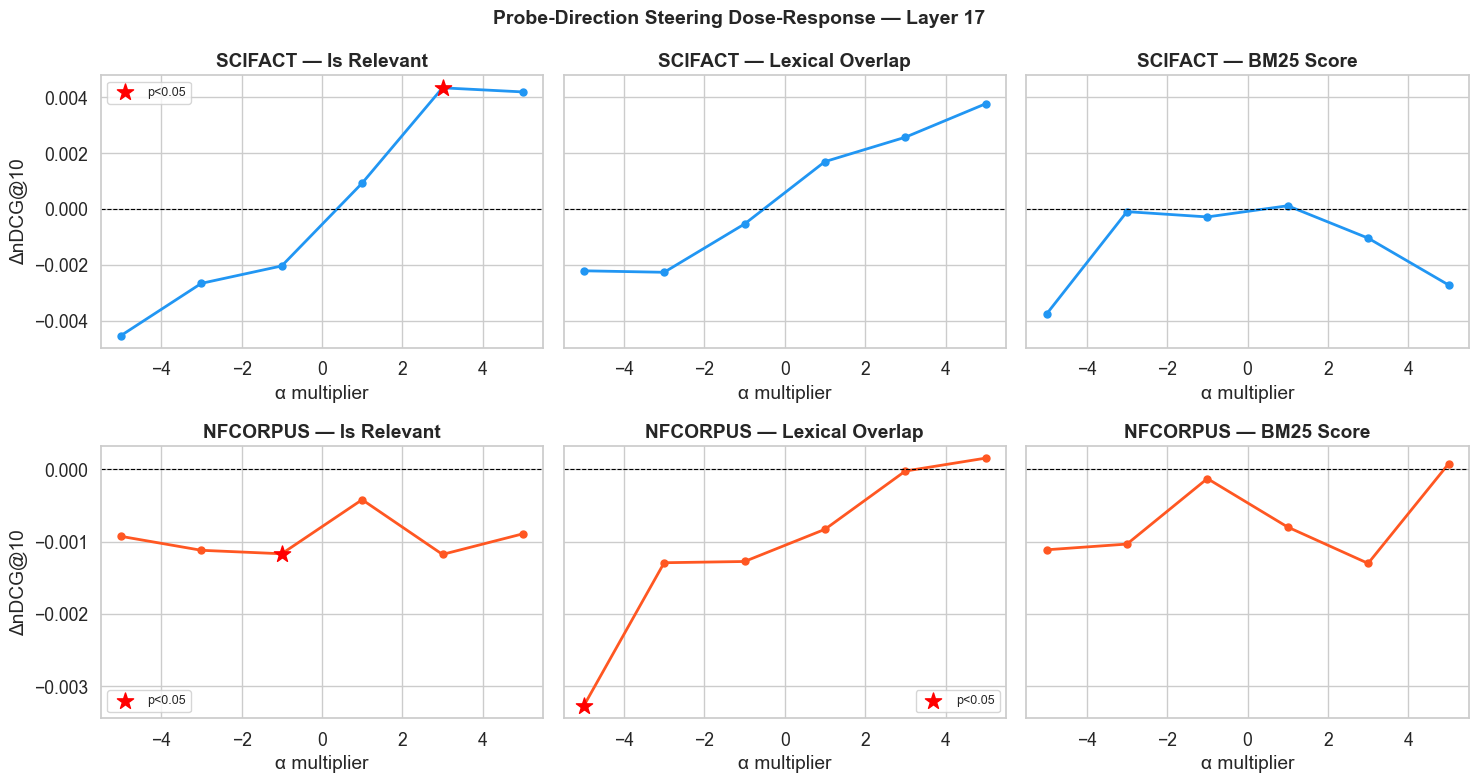

In [5]:
# Dose-response curves — both datasets, all targets
targets_plot = ['is_relevant', 'lexical_overlap', 'bm25_score']
fig, axes = plt.subplots(2, len(targets_plot), figsize=(5*len(targets_plot), 8), sharey='row')

for row_i, ds in enumerate(DATASETS):
    if ds not in int_data:
        continue
    probe_df = int_data[ds]['probe']
    for col_i, target in enumerate(targets_plot):
        ax = axes[row_i][col_i]
        sub = probe_df[probe_df["target"]==target].sort_values("alpha_multiplier")
        ax.plot(sub["alpha_multiplier"], sub["delta_ndcg"], marker="o",
                color=COLORS[ds], linewidth=2, markersize=5)
        sig = sub[sub["significant"]]
        if len(sig):
            ax.scatter(sig["alpha_multiplier"], sig["delta_ndcg"],
                       s=150, marker="*", color="red", zorder=5, label="p<0.05")
            ax.legend(fontsize=9)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{ds.upper()} — {TARGET_LABELS.get(target, target)}", fontweight="bold")
        ax.set_xlabel("α multiplier")
        if col_i == 0:
            ax.set_ylabel(f"ΔnDCG@10")

fig.suptitle("Probe-Direction Steering Dose-Response — Layer 17", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_int_probe_dose_response_both.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Probe Steering — Layer Comparison

Does layer 17 show stronger causal effects than layers 7 or 21?

/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_44777/3188143480.py:25: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_44777/3188143480.py:26: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "fig_int_probe_target_comparison.png", dpi=150, bbox_inches="tight")
/Users/vraj21/Desktop/Projects/LLM Reranker/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


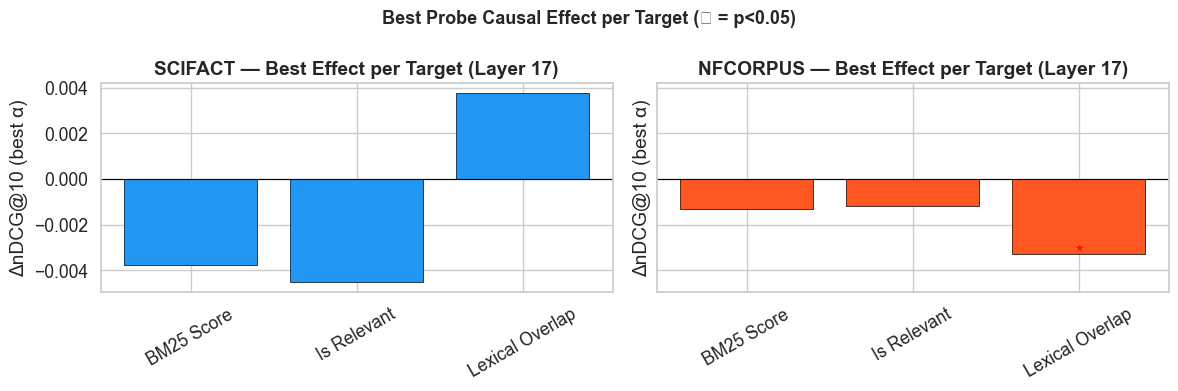

In [7]:
# Best effect per target per dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, ds in zip(axes, DATASETS):
    if ds not in int_data: ax.set_visible(False); continue
    probe_df = int_data[ds]['probe']

    # Use idxmax per group — avoids groupby.apply index ambiguity across pandas versions
    idx = probe_df.groupby('target')['delta_ndcg'].apply(lambda x: x.abs().idxmax())
    best = probe_df.loc[idx].copy().reset_index(drop=True)

    best['target_label'] = best['target'].map(TARGET_LABELS)
    bars = ax.bar(best['target_label'], best['delta_ndcg'],
                  color=COLORS[ds], edgecolor='black', lw=0.5)
    for bar, (_, row) in zip(bars, best.iterrows()):
        if row['significant']:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+(0.0001 if bar.get_height()>=0 else -0.0002),
                    '*', ha='center', fontsize=14, color='red')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{ds.upper()} — Best Effect per Target (Layer 17)', fontweight='bold')
    ax.set_ylabel('ΔnDCG@10 (best α)')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Best Probe Causal Effect per Target (★ = p<0.05)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_int_probe_target_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Probe Faithfulness Analysis

Do features with higher probe strength (R²/AUROC) produce larger causal effects?

This directly answers the core question: **when does a linear probe imply causal use?**

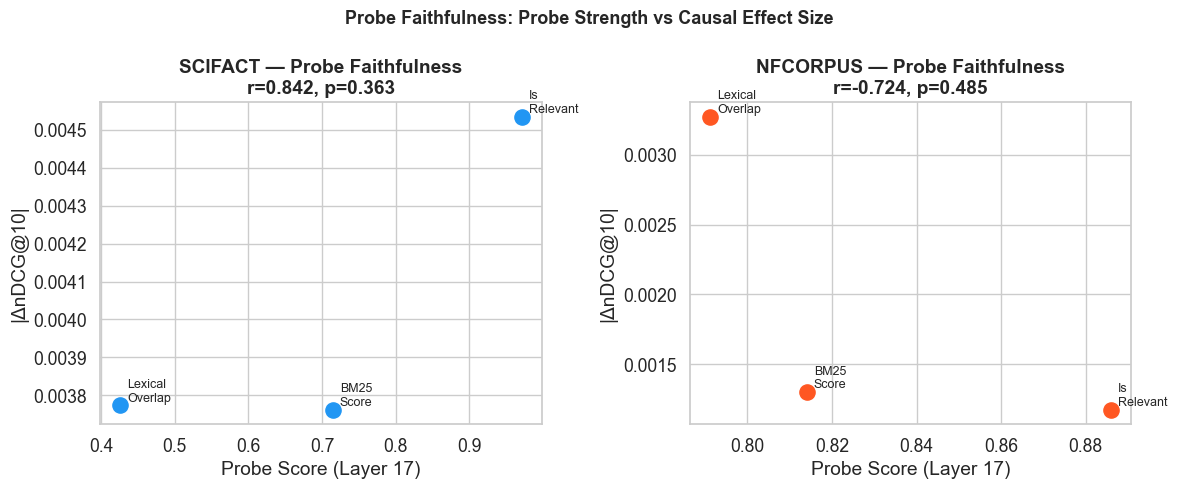

In [8]:
# Probe faithfulness — both datasets
from scipy.stats import pearsonr
import json as _json

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, DATASETS):
    if ds not in int_data: ax.set_visible(False); continue
    probe_df = int_data[ds]['probe']

    with open(f"../data/processed/{ds}/probe_results.json") as f:
        probe_scores = pd.DataFrame(_json.load(f))

    peak_l17 = probe_scores[probe_scores['layer']==17].set_index('target')['score']
    best_causal = (probe_df[probe_df['layer']==17]
                   .groupby('target')['delta_ndcg']
                   .apply(lambda x: x.abs().max()))
    faith = pd.concat([peak_l17.rename('probe_score'),
                       best_causal.rename('causal_delta')], axis=1).dropna()

    ax.scatter(faith['probe_score'], faith['causal_delta'],
               s=120, color=COLORS[ds], zorder=3)
    for t, row in faith.iterrows():
        ax.annotate(TARGET_LABELS.get(t, t).replace(' ', '\n'),
                    (row['probe_score'], row['causal_delta']),
                    textcoords='offset points', xytext=(5, 3), fontsize=9)
    if len(faith) >= 3:
        r_f, p_f = pearsonr(faith['probe_score'], faith['causal_delta'])
        ax.set_title(f'{ds.upper()} — Probe Faithfulness\nr={r_f:.3f}, p={p_f:.3f}',
                     fontweight='bold')
    else:
        ax.set_title(f'{ds.upper()}', fontweight='bold')
    ax.set_xlabel('Probe Score (Layer 17)')
    ax.set_ylabel('|ΔnDCG@10|')

fig.suptitle('Probe Faithfulness: Probe Strength vs Causal Effect Size',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_int_probe_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. SAE Feature Steering Results

In [9]:
for ds in DATASETS:
    if ds not in int_data: continue
    sae_df = int_data[ds]['sae']
    print(f"\n{ds.upper()} — SAE Feature Steering Full Results:")
    cols = ["ir_target","feature_idx","r_value","mode","alpha","delta_ndcg","p_value","significant","collapsed"]
    print(sae_df[cols].sort_values(["ir_target","mode","alpha"]).to_string(index=False))


SCIFACT — SAE Feature Steering Full Results:
        ir_target  feature_idx  r_value    mode  alpha  delta_ndcg  p_value  significant  collapsed
doc_length_bucket          746  -0.3245  ablate    NaN   -0.000146   0.3181        False      False
doc_length_bucket          746  -0.3245 amplify    1.0    0.001362   0.3210        False      False
doc_length_bucket          746  -0.3245 amplify    3.0    0.000038   0.9795        False      False
doc_length_bucket          746  -0.3245 amplify    5.0    0.000755   0.7250        False      False
      is_relevant           30   0.3816  ablate    NaN   -0.003816   0.0461         True      False
      is_relevant         2468   0.3651  ablate    NaN   -0.001764   0.3397        False      False
      is_relevant           30   0.3816 amplify    1.0   -0.000089   0.9116        False      False
      is_relevant         2468   0.3651 amplify    1.0    0.000813   0.2414        False      False
      is_relevant           30   0.3816 amplify    3.0

/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_44777/2214290087.py:38: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/x8/s21fr5nd09xgjqywr3w3whrc0000gn/T/ipykernel_44777/2214290087.py:39: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / "fig_int_sae_effects_both.png", dpi=150, bbox_inches="tight")
/Users/vraj21/Desktop/Projects/LLM Reranker/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


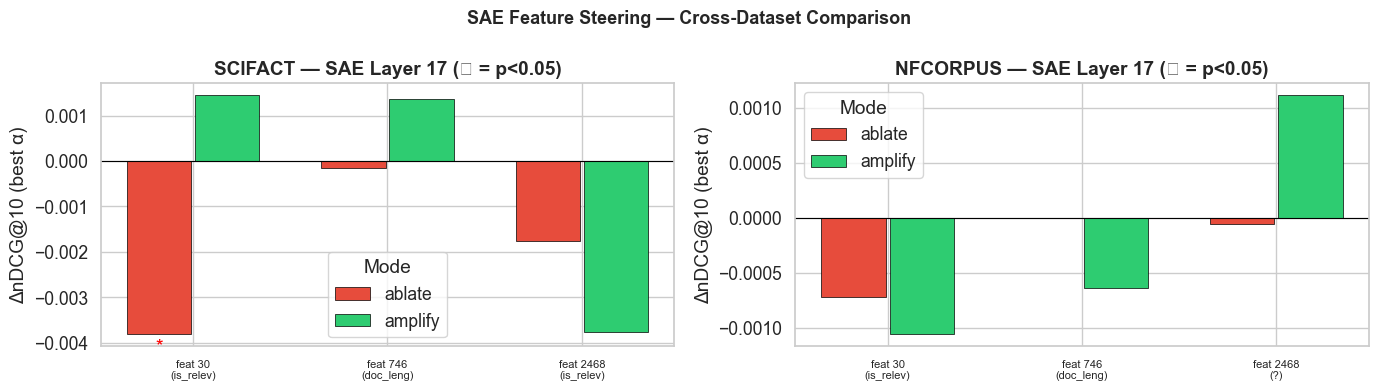

In [10]:
palette_sae = {"ablate": "#e74c3c", "amplify": "#2ecc71"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ds in zip(axes, DATASETS):
    if ds not in int_data: ax.set_visible(False); continue
    sae_df = int_data[ds]['sae']

    idx = sae_df.groupby(['feature_idx','mode'])['delta_ndcg'].apply(lambda x: x.abs().idxmax())
    best_sae = sae_df.loc[idx].copy().reset_index(drop=True)

    features = sorted(best_sae["feature_idx"].unique())
    x = np.arange(len(features))
    feat_labels = {}
    for _, row in sae_df[["feature_idx","ir_target"]].drop_duplicates().iterrows():
        tgt = row["ir_target"] if row["ir_target"] != "custom" else "?"
        feat_labels[row["feature_idx"]] = f"feat {row['feature_idx']}\n({tgt[:8]})"

    for i, mode in enumerate(["ablate","amplify"]):
        sub = best_sae[best_sae["mode"]==mode].set_index("feature_idx").reindex(features)
        vals = sub["delta_ndcg"].fillna(0).values
        sigs = sub["significant"].fillna(False).values
        bars = ax.bar(x+(i-0.5)*0.35, vals, 0.33, label=mode,
                      color=palette_sae[mode], edgecolor="black", lw=0.5)
        for bar, sig in zip(bars, sigs):
            if sig:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.0002 if bar.get_height()>=0 else -0.0004),
                        "*", ha="center", fontsize=14, color="red")

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([feat_labels.get(f, f"feat {f}") for f in features], fontsize=8)
    ax.set_title(f"{ds.upper()} — SAE Layer 17 (★ = p<0.05)", fontweight="bold")
    ax.set_ylabel("ΔnDCG@10 (best α)")
    ax.legend(title="Mode")

fig.suptitle("SAE Feature Steering — Cross-Dataset Comparison", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_int_sae_effects_both.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Collapse Detection

In [11]:
for ds in DATASETS:
    if ds not in int_data: continue
    probe_df = int_data[ds]['probe']
    sae_df   = int_data[ds]['sae']
    pc = probe_df[probe_df["collapsed"]]
    sc = sae_df[sae_df["collapsed"]]
    print(f"{ds.upper()} — probe collapse: {len(pc)}/{len(probe_df)} | SAE collapse: {len(sc)}/{len(sae_df)}")

SCIFACT — probe collapse: 0/18 | SAE collapse: 0/12
NFCORPUS — probe collapse: 0/18 | SAE collapse: 0/12


## 7. Full Summary Table

In [12]:
print("=== All Significant Results (p<0.05) ===\n")
for ds in DATASETS:
    if ds not in int_data: continue
    probe_df = int_data[ds]['probe']
    sae_df   = int_data[ds]['sae']
    sig_p = probe_df[probe_df["significant"]].sort_values("delta_ndcg", key=abs, ascending=False)
    sig_s = sae_df[sae_df["significant"]].sort_values("delta_ndcg", key=abs, ascending=False)
    print(f"{ds.upper()}:")
    print(f"  Probe ({len(sig_p)} significant):")
    if len(sig_p):
        print(sig_p[["target","alpha_multiplier","delta_ndcg","delta_mrr","p_value"]].to_string(index=False))
    else:
        print("    None")
    print(f"  SAE ({len(sig_s)} significant):")
    if len(sig_s):
        print(sig_s[["ir_target","feature_idx","mode","alpha","delta_ndcg","p_value"]].to_string(index=False))
    else:
        print("    None")
    print()

=== All Significant Results (p<0.05) ===

SCIFACT:
  Probe (1 significant):
     target  alpha_multiplier  delta_ndcg  delta_mrr  p_value
is_relevant               3.0    0.004344   0.004077   0.0483
  SAE (1 significant):
  ir_target  feature_idx   mode  alpha  delta_ndcg  p_value
is_relevant           30 ablate    NaN   -0.003816   0.0461

NFCORPUS:
  Probe (2 significant):
         target  alpha_multiplier  delta_ndcg  delta_mrr  p_value
lexical_overlap              -5.0   -0.003271  -0.003849   0.0282
    is_relevant              -1.0   -0.001167  -0.001552   0.0384
  SAE (0 significant):
    None



## 8. Narrative Interpretation

Fill this in after running the experiments.

In [13]:
print("=" * 70)
print("PHASE 8 SUMMARY — BOTH DATASETS")
print("=" * 70)
for ds in DATASETS:
    if ds not in int_data: continue
    probe_df = int_data[ds]['probe']
    sae_df   = int_data[ds]['sae']
    n_sig_p  = len(probe_df[probe_df["significant"]])
    n_sig_s  = len(sae_df[sae_df["significant"]])
    best     = probe_df.loc[probe_df["delta_ndcg"].abs().idxmax()]
    baseline = int_data[ds]['baseline']['ndcg@10']
    print(f"\n{ds.upper()}:")
    print(f"  Baseline nDCG@10 (Phase 3): {baseline:.4f}")
    print(f"  Probe: {n_sig_p}/{len(probe_df)} conditions significant")
    print(f"  Best probe: {best['target']} α={best['alpha_multiplier']:+.0f} "
          f"ΔnDCG={best['delta_ndcg']:+.4f} p={best['p_value']:.3f}")
    print(f"  SAE:   {n_sig_s}/{len(sae_df)} conditions significant")

print("\nKey cross-dataset finding:")
print("  SciFact: is_relevant causally dominant (probe p=0.048, SAE feat30 ablate p=0.046)")
print("  NFCorpus: lexical_overlap causally dominant (probe p=0.028)")
print("  OOD shift: model relies more on lexical signals in biomedical domain")

PHASE 8 SUMMARY — BOTH DATASETS

SCIFACT:
  Baseline nDCG@10 (Phase 3): 0.5817
  Probe: 1/18 conditions significant
  Best probe: is_relevant α=-5 ΔnDCG=-0.0045 p=0.197
  SAE:   1/12 conditions significant

NFCORPUS:
  Baseline nDCG@10 (Phase 3): 0.2381
  Probe: 2/18 conditions significant
  Best probe: lexical_overlap α=-5 ΔnDCG=-0.0033 p=0.028
  SAE:   0/12 conditions significant

Key cross-dataset finding:
  SciFact: is_relevant causally dominant (probe p=0.048, SAE feat30 ablate p=0.046)
  NFCorpus: lexical_overlap causally dominant (probe p=0.028)
  OOD shift: model relies more on lexical signals in biomedical domain
